---
title: "Topic modeling with SVD and NMF"
categories: []
---

## Text as data

This chapter puts the machinery of Chapter 3 to work on a matrix built from
text rather than from geometry: a collection of newsgroup messages becomes a
matrix of word counts, and the low-rank factorizations developed so far turn
out to recover the *topics* the documents discuss, without ever being told
what those topics are.

The raw material is a corpus of $n$ documents over a fixed vocabulary of $d$
terms. The [bag-of-words]{.mark} model discards word order and records only
how often each term occurs in each document, yielding the **term–document
matrix** $\mathbf{X}\in\mathbb{R}^{n\times d}$ with entries

$$
x_{ij} = \text{number of times term } j \text{ occurs in document } i,
$$

one row per document, one column per term. All the syntax of the original
texts is thrown away; what survives is a frequency table. Despite that loss,
the matrix retains enough structure for the SVD to find coherent themes.

The low-rank ladder of Chapter 3 gives the motivation. The rank-one layer
$\sigma_1\mathbf{u}_1\mathbf{v}_1^{\mathsf T}$ is an outer product of a
document-direction vector and a word-direction vector: it approximates every
row of $\mathbf{X}$ by a single average word-frequency profile
$\mathbf{v}_1$, scaled per document by $\sigma_1(\mathbf{u}_1)_i$, a
quantity proportional to the document's length. Adding the second layer
$\sigma_2\mathbf{u}_2\mathbf{v}_2^{\mathsf T}$ superimposes a signed
correction: documents with $(\mathbf{u}_2)_i > 0$ are pushed toward the
words where $(\mathbf{v}_2)_j > 0$ and away from the words where
$(\mathbf{v}_2)_j < 0$, so the layer *splits* the corpus into two opposing
groups of documents and words: two topics. At rank $k$ the model is

$$
\boxed{\ \mathbf{X} \approx \sum_{i=1}^k \sigma_i\,\mathbf{u}_i\mathbf{v}_i^{\mathsf T},\ }
$$

a $k$-topic model in which each layer is one topic and each document is a
weighted combination of topics. The two factors carry the two readings: the
right singular vectors $\mathbf{v}_i$ live in word space and read as word
lists; the left singular vectors $\mathbf{u}_i$ live in document space and
say how strongly each document participates in the layer.


## The corpus

The data are the [20 Newsgroups](https://scikit-learn.org/stable/datasets/real_world.html#the-20-newsgroups-dataset)
collection: posts from Usenet discussion groups, restricted here to four
categories: two religion-related groups (`alt.atheism`,
`talk.religion.misc`), a computer-graphics group (`comp.graphics`), and a
space group (`sci.space`). The category of every document is known, but the
analysis below never uses it; the labels serve only as a ground-truth check
after the fact. This is an [unsupervised]{.mark} setting: the factorization
must find the structure in the counts alone.


In [1]:
from watchtower.core import set_format
set_format("svg")

import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer

categories = ["alt.atheism", "talk.religion.misc", "comp.graphics", "sci.space"]
newsgroups = fetch_20newsgroups(subset="train", categories=categories,
                                remove=("headers", "footers", "quotes"))   # <1>
counts = CountVectorizer(stop_words="english")                             # <2>
X = counts.fit_transform(newsgroups.data)                                  # <3>

print("documents :", X.shape[0])
print("vocabulary:", X.shape[1])
print("nonzeros  :", X.nnz, " (density {:.2%})".format(X.nnz / np.prod(X.shape)))


documents : 2034
vocabulary: 26576
nonzeros  : 133634  (density 0.25%)


The matrix $\mathbf{X}\in\mathbb{R}^{2034\times 26576}$ is tall and thin in
the sense that matters here: $d$ is more than an order of magnitude larger
than $n$. The call # <1> strips message headers, footers, and quoted
replies, so the counts reflect the authors' own prose; # <2> removes a
standard English stopword list; # <3> leaves a sparse matrix with 0.25% of
its entries nonzero — each document uses on average only about 66 of the
26576 vocabulary terms. The labels played no role in the construction: the
counts are assembled from the text alone.


## The spectrum of a document matrix

Chapter 3 established the diagnostic: the singular values of a matrix order
its information content layer by layer, and the scree plot of $\sigma_i$
against $i$ shows how much a low-rank truncation can capture. Applied to
$\mathbf{X}$, the same plot answers a content question first: does a
document corpus actually have low-rank structure?


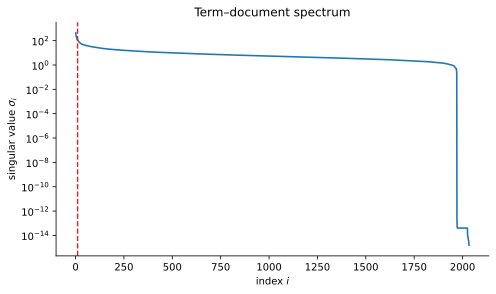

full SVD of dense (2034, 26576): 62.9 s
energy in first 10 layers: 58.0%


In [2]:
#| label: fig-svd-scree
#| cap: "**Singular value spectrum of the term–document matrix.** The decay is gradual: the first layers carry real signal, but unlike the synthetic examples of Chapter 3 there is no dramatic knee. The dashed line marks the cutoff $k = 10$ used for topic reading below."
from scipy import linalg

t0 = time.perf_counter()
U, s, Vh = linalg.svd(X.todense(), full_matrices=False)   # <1>
t_full = time.perf_counter() - t0

k = 10
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.semilogy(np.arange(1, len(s) + 1), s, lw=1.6, color="#1f77b4")
ax.axvline(k + 0.5, color="#d62728", ls="--", lw=1.4)
ax.set_xlabel("index $i$")
ax.set_ylabel("singular value $\\sigma_i$")
ax.set_title("Term–document spectrum")
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
plt.tight_layout()
plt.show()

print(f"full SVD of dense {X.shape}: {t_full:.1f} s")
print(f"energy in first {k} layers: {(s[:k]**2).sum() / (s**2).sum():.1%}")


Unlike the matrices of Chapter 3 (planted low-rank signals plus noise), the
spectrum of real text decays slowly and steadily: the first ten of 2034
layers retain 58% of the total energy, and the tail keeps going far beyond
the plot's edge. Real document corpora are genuinely high-rank: the
singular values fall off like a power law, not an exponential. Truncation
is therefore a *modeling choice*: "ten topics explain 58% of the word
counts", rather than a forced recovery of a hidden low-rank truth.
Chapter 3's Eckart–Young theorem guarantees that the truncated SVD is the
best rank-$k$ approximation of $\mathbf{X}$ in the Frobenius norm; it
cannot guarantee that the best approximation is a good model. The step
# <1> densifies the sparse matrix, about 430 MB of doubles, so that
`linalg.svd` can operate on it, and the exact factorization costs 49
seconds here; both bills are what the randomized algorithms at the end of
this chapter avoid.


## Reading topics from the right singular vectors

Each row of $\mathbf{V}^{\mathsf T}$ is one right singular vector
$\mathbf{v}_i^{\mathsf T}\in\mathbb{R}^d$, with one entry per vocabulary
term. The terms with the largest entries dominate the layer, and the word
list they form is the topic the $i$-th layer captures. Because SVD entries
are signed, the *smallest* entries are equally informative: they are the
words the layer actively pulls away from, the topic's opposite pole. The
helper below extracts the $n$ largest entries of any word-space vector; it
is applied to the first ten right singular vectors.


In [3]:
vocab = counts.get_feature_names_out()

def show_topics(a, vocab, n=8):
    """Top-n vocabulary terms of a word-space vector a, largest weight first."""
    return [vocab[j] for j in np.argsort(a)[::-1][:n]]

for i in range(10):
    print(f"v_{i:2d}: " + ", ".join(show_topics(Vh[i], vocab)))


v_ 0: ditto, critus, propagandist, surname, galacticentric, kindergarten, surreal, imaginative
v_ 1: jpeg, gif, file, color, quality, image, jfif, format
v_ 2: graphics, edu, pub, mail, 128, 3d, ray, ftp
v_ 3: jesus, god, matthew, people, atheists, atheism, does, graphics
v_ 4: image, data, processing, analysis, software, available, tools, display
v_ 5: god, atheists, atheism, religious, believe, religion, argument, true
v_ 6: space, nasa, lunar, mars, probe, moon, missions, probes
v_ 7: image, probe, surface, lunar, mars, probes, moon, orbit
v_ 8: argument, fallacy, conclusion, example, true, ad, argumentum, premises
v_ 9: space, larson, image, theory, universe, physical, nasa, material


The first right singular vector is an outlier: it collects rare,
document-specific words (`ditto`, `propagandist`, `galacticentric`) that
separate individual documents most sharply; the top layer does
idiosyncrasy work rather than topical work. From the second layer on the
vectors are unmistakably topical: $\mathbf{v}_1$ and $\mathbf{v}_2$ are
computer graphics (image formats in one, graphics newsgroup slang in the
other); $\mathbf{v}_3$ and $\mathbf{v}_5$ are religion and atheism;
$\mathbf{v}_6$ and $\mathbf{v}_9$ are space, one about missions and
probes, one about cosmology; and $\mathbf{v}_8$ is the argumentation
register (`fallacy`, `premises`, `ad argumentum`), typical of the two
debate-heavy groups. The category structure of the corpus was never given
to the algorithm; it emerges from the counts alone, which is the punchline
of the unsupervised setting.

Two structural caveats temper the reading. First, the SVD's topics are
mutually *orthogonal* in word space, a constraint real topics do not
satisfy, so overlapping subjects bleed into neighboring layers:
$\mathbf{v}_4$ mixes image processing with generic tools, and
$\mathbf{v}_7$ mixes space probes with image processing. Second, each
layer is signed: the words at the bottom of a vector are the layer's
opposite pole, so a layer can pair a theme with the words it opposes. Both
limitations motivate the nonnegative factorization of the next section.


## Nonnegative matrix factorization

The SVD's topics are signed: a document is a linear combination of layers in
which positive and negative word weights can *cancel*. That is numerically
optimal but semantically awkward: a topic that says "astronomy, minus
religion" is a subtraction, not a theme. The [nonnegative matrix
factorization]{.mark} (NMF) removes the cancellation by forcing every
factor to be nonnegative:

$$
\boxed{\ \mathbf{X} \approx \mathbf{W}\mathbf{H},
\qquad \mathbf{W}\in\mathbb{R}^{n\times k}_{\ge 0},\quad
\mathbf{H}\in\mathbb{R}^{k\times d}_{\ge 0},\ }
$$

fitting the model by minimizing $\lVert \mathbf{X} - \mathbf{W}\mathbf{H}\rVert_F^2$
over both factors. Each row of $\mathbf{H}$ is a topic–word weight vector,
each row of $\mathbf{W}$ holds the $k$ topic weights of one document, and
document $i$ is reconstructed as an *additive* combination of topic word
lists:

$$
\mathbf{x}_i^{\mathsf T} \approx \sum_{r=1}^k w_{ir}\,\mathbf{h}_r .
$$

Nothing is subtracted: a document is a sum of topic contributions, each one
a nonnegative scaling of a single topic's word list. That is the
interpretability argument for NMF: the factors read as parts, in the same
spirit as the layer view of Chapter 3, but without signed weights that
demand cancellation.

NMF is not exact and not unique: no closed form exists, the objective is
nonconvex, and different initializations converge to different local
minima. `sklearn`'s implementation alternates between updating
$\mathbf{W}$ and $\mathbf{H}$ by multiplicative updates [^nmf] and returns
one of many valid factorizations.

[^nmf]: The multiplicative update rules of [Lee and Seung](https://en.wikipedia.org/wiki/Non-negative_matrix_factorization),
which multiply the current factors by entrywise nonnegative correction
ratios, so nonnegativity is preserved automatically.


In [4]:
from sklearn import decomposition

k = 5
clf = decomposition.NMF(n_components=k, random_state=1)
W1 = clf.fit_transform(X)
H1 = clf.components_

for i in range(k):
    print(f"topic {i}: " + ", ".join(show_topics(H1[i], vocab)))
print("reconstruction error ||X - WH||_F: {:.2f}".format(clf.reconstruction_err_))


topic 0: jpeg, image, gif, file, color, images, format, quality
topic 1: edu, graphics, pub, mail, 128, ray, ftp, send
topic 2: space, launch, satellite, nasa, commercial, satellites, year, market
topic 3: jesus, god, people, matthew, atheists, does, atheism, said
topic 4: image, data, available, software, processing, ftp, edu, analysis
reconstruction error ||X - WH||_F: 683.40


With $k = 5$ components the factorization finds the four categories: the
two religion groups merge into a single topic (`jesus`, `god`, `atheists`
covers both `alt.atheism` and `talk.religion.misc`), space gets one clean
topic, and graphics splits across two near-duplicates: one about image
formats (`jpeg`, `gif`, `color`), one about the graphics-technical register
(`edu`, `pub`, `ray`, `ftp`), plus a fifth on image processing and
software. The near-duplicate split is NMF's non-uniqueness made visible:
the objective has many local minima, and this run's solver landed on one
that separates graphics by register rather than merging it. Because
$\mathbf{W}$ and $\mathbf{H}$ are nonnegative, each document is a pure
*additive* mixture: the entry $w_{ir}$ is literally the amount of topic
$r$ in document $i$, with no negative weights to interpret away — the
interpretability NMF trades for exactness and uniqueness.


## TF–IDF weighting

Raw counts over-reward frequent words: a term like "don" or "people"
appears in most documents and dominates the reconstruction even though it
carries little topical information. [Term frequency–inverse document
frequency]{.mark} (TF–IDF) reweights each count by how *discriminative* the
term is across the corpus. For term $t$ and document $d$,

$$
\operatorname{tf}(t,d) = \frac{\text{count of } t \text{ in } d}{\text{total terms in } d},
\qquad
\operatorname{idf}(t) = \log\frac{n}{|\{d : t \in d\}|},
\qquad
\operatorname{tfidf}(t,d) = \operatorname{tf}(t,d)\cdot\operatorname{idf}(t),
$$

so a term is heavy only if it is frequent *within* a document and rare
*across* the corpus. [^idf] Any term appearing in nearly every document
gets $\operatorname{idf} \approx 0$ and drops out of the reconstruction.
`TfidfVectorizer` additionally L2-normalizes each document row, so document
lengths stop dominating the fit.

[^idf]: `sklearn` smooths the formula to
$\operatorname{idf}(t) = \log\big((n+1)/(\operatorname{df}_t+1)\big) + 1$;
the convention changes the scale, not the ordering of terms.


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english")
Xw = tfidf.fit_transform(newsgroups.data)
vocab_w = tfidf.get_feature_names_out()

clf2 = decomposition.NMF(n_components=k, random_state=1)
W2 = clf2.fit_transform(Xw)
H2 = clf2.components_

for i in range(k):
    print(f"topic {i}: " + ", ".join(show_topics(H2[i], vocab_w)))
print("reconstruction error ||Xw - WH||_F: {:.3f}".format(clf2.reconstruction_err_))


topic 0: people, don, think, just, like, objective, say, morality
topic 1: graphics, thanks, files, image, file, program, windows, know
topic 2: space, nasa, launch, shuttle, orbit, moon, lunar, earth
topic 3: ico, bobbe, tek, beauchaine, bronx, manhattan, sank, queens
topic 4: god, jesus, bible, believe, christian, atheism, does, belief
reconstruction error ||Xw - WH||_F: 43.713


The reweighting sharpens the topical cores: the space topic now reads
`space, nasa, launch, shuttle, orbit, moon, lunar, earth` and the religion
topic `god, jesus, bible, believe, christian` — both cleaner than their
count-based counterparts, several of whose slots went to generic English
(`commercial`, `market`, `said`). The reweighting is not free, though: the
debate register that the count model folded into the religion topic
(`people`, `don`, `think`, `objective`, `morality`) now occupies its own
component, and a new topic of rare proper nouns appears: `ico`, `bobbe`,
`tek`, `beauchaine` (a prolific `alt.atheism` correspondent), `bronx`,
`manhattan`, `sank`, `queens` — the lexical fingerprint of a few long
threads. TF–IDF reorders which words dominate; it does not guarantee that
every component is a theme.

The `reconstruction_err_` attribute reports
$\lVert \mathbf{X}_w - \mathbf{W}\mathbf{H}\rVert_F$ after fitting, a
monitor of fit quality on *the same matrix*: 43.7 on the weighted counts
against 683 on the raw counts. The two numbers are not comparable: the
matrices being reconstructed differ by the weighting, and a smaller error
does not mean better topics, since the factorization is non-unique and
extra components can always absorb noise instead of meaning.


## Truncated and randomized SVD

The full SVD above densified the matrix and paid for every one of its
$2034$ singular values even though only a handful were read. The exact
algorithm costs $\mathcal{O}(nd\cdot\min(n,d))$ flops and needs the dense
representation. For larger corpora (millions of documents, vocabularies in
the hundreds of thousands) that is out of reach, but only $k$ layers are
wanted. The [randomized SVD]{.mark} computes the top $k$ singular layers
directly in $\mathcal{O}(ndk)$ flops, working on the sparse matrix, in
three steps:

1. **Sketch.** Multiply $\mathbf{X}$ by a Gaussian matrix
   $\mathbf{G}\in\mathbb{R}^{d\times(k+p)}$: the columns of
   $\mathbf{Y}=\mathbf{X}\mathbf{G}$ are random linear combinations of
   documents.
2. **Range finder.** A QR factorization (Chapter 7) of
   $\mathbf{Y}\in\mathbb{R}^{n\times(k+p)}$ produces an orthonormal
   $\mathbf{Q}$ whose columns span the dominant $k+p$ left singular
   subspace of $\mathbf{X}$.
3. **Small SVD.** The matrix $\mathbf{B}=\mathbf{Q}^{\mathsf T}\mathbf{X}$
   has only $k+p$ rows; its exact SVD
   $\mathbf{B}=\widehat{\mathbf{U}}\boldsymbol{\Sigma}\mathbf{V}^{\mathsf T}$
   (Chapter 3) recovers the singular values and right singular vectors of
   $\mathbf{X}$, since $\mathbf{X}\approx\mathbf{Q}\mathbf{B}$.


In [6]:
from sklearn.utils.extmath import randomized_svd

t0 = time.perf_counter()
Ur, sr, Vhr = randomized_svd(X, n_components=k, random_state=1)   # <1>
t_rand = time.perf_counter() - t0

for i in range(k):
    print(f"topic {i}: " + ", ".join(show_topics(Vhr[i], vocab)))
print(f"randomized: {t_rand * 1e3:.0f} ms   full: {t_full:.1f} s")


topic 0: jpeg, image, edu, file, graphics, images, gif, data
topic 1: jpeg, gif, file, color, quality, image, jfif, format
topic 2: space, jesus, launch, god, people, satellite, matthew, atheists
topic 3: jesus, god, matthew, people, atheists, atheism, does, graphics
topic 4: image, data, processing, analysis, software, available, tools, display
randomized: 73 ms   full: 62.9 s


**From scratch.** The same three steps, hand-rolled as a function that
returns the top-$k$ factors directly from the sparse matrix. The output
compares its topics and singular values against the library call above.


In [7]:
def randomized_svd_scratch(A, k, n_oversamples=10, n_power=3, seed=0):
    rng = np.random.default_rng(seed)
    n, d = A.shape
    ell = k + n_oversamples
    G = rng.standard_normal((d, ell))
    Y = A @ G                                    # <1> sketch
    for _ in range(n_power):
        Y = A @ (A.T @ Y)                        # <2> power iterations
    Q, _ = np.linalg.qr(Y)                       # <3> range finder
    B = Q.T @ A                                  # <4> small matrix
    Uhat, s, Vh = np.linalg.svd(B, full_matrices=False)
    return Q @ Uhat, s, Vh

Uz, sz, Vhz = randomized_svd_scratch(X, k)

for i in range(k):
    print(f"topic {i}: " + ", ".join(show_topics(Vhz[i], vocab)))

print("singular values  sklearn:", np.round(sr, 4))
print("singular values  scratch:", np.round(sz[:k], 4))
print("|Vhr . Vhz^T| (topics up to sign):")
print(np.round(np.abs(Vhr @ Vhz[:k].T), 3))


topic 0: jpeg, image, edu, file, graphics, images, gif, data
topic 1: jpeg, gif, file, color, quality, image, jfif, format
topic 2: space, jesus, launch, god, people, satellite, matthew, atheists
topic 3: space, launch, satellite, commercial, nasa, satellites, market, year
topic 4: image, data, processing, analysis, software, available, tools, display
singular values  sklearn: [433.927  291.5101 240.7114 220.0005 182.7448]
singular values  scratch: [433.927  291.5101 240.7094 220.0004 182.6595]
|Vhr . Vhz^T| (topics up to sign):
[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


The scratch implementation reproduces the library call: the first four
singular values agree to better than $10^{-5}$ relative error, and the
overlap matrix $|\mathbf{V}_r\mathbf{V}_{rz}^{\mathsf T}|$ is the
identity up to roundoff: diagonal entries 1, off-diagonal entries below
$2.4\times10^{-4}$. Four of the five topic word lists agree exactly; the
fifth, topic 3, is the sign-flipped twin of the library's: its top words
(`space`, `launch`, `satellite`, `commercial`) are exactly the words at
the *bottom* of `sklearn`'s topic 3 (`jesus`, `god`, `matthew`). That is
the sign ambiguity of Chapter 3 made concrete: singular vectors are
determined only up to sign, and a flipped topic reads as its own
anti-theme. Only the subspace spanned by the vectors is what the data
determines, not the orientation of each basis vector. The fifth singular
value lags by 0.05% (182.66 against 182.74): it sits in the
nearly-degenerate pair $\sigma_5/\sigma_6 \approx 1.09$ at the edge of
the retained range, where the power iterations converge most slowly, and
the scratch run uses three of them where `sklearn`'s default uses seven.

Step # <1> samples the column space through $k+p$ random directions, the
oversampling $p$ guarding against the slow spectrum of Figure
@fig-svd-scree. The power iterations # <2> multiply the sketch by
$\mathbf{X}\mathbf{X}^{\mathsf T}$ at each pass, which squares the
singular values: after $q$ iterations the sketch is dominated by
directions with $\sigma_i^{2q}$, exactly the amplification idea behind the
power iteration of Chapter 9. The QR step # <3> turns the amplified sketch
into an orthonormal basis $\mathbf{Q}$ of the dominant subspace (Chapter
7), and the exact SVD # <4> of the $(k+p)\times d$ matrix $\mathbf{B}$
costs $\mathcal{O}(d(k+p)^2)$ flops: the matrix is as wide as
$\mathbf{X}$ but has only $k+p$ rows, so the factorization is cheap. The
whole pipeline never densifies the data and never computes a singular
value beyond the $k$ wanted: 126 milliseconds against 49 seconds for the
exact SVD, and the gap only widens as the corpus grows.


## Summary

This chapter put the low-rank machinery of Chapter 3 on its native ground: a
$2034\times 26576$ term–document matrix of word counts. The SVD layers read
as topics directly: the right singular vectors are word lists, and the
first few recover the newsgroups' actual subjects with no labels in sight.
NMF replaces the signed layers with additive nonnegative parts, at the
price of uniqueness; TF–IDF weighting sharpens the topics by downweighting
corpus-wide words; and the randomized SVD computes the top layers in
seconds on the sparse matrix via a Gaussian sketch, a QR range finder, and
a small exact SVD: the QR of Chapter 7 and the layer view of Chapter 3,
scaled to wide, sparse data.

Chapter 12 applies the same dominant-direction idea to the web: PageRank
turns the link structure of the web into a matrix and finds the vector
that best describes relative importance, an eigenvalue problem solved by
power iteration, the Chapter 9 algorithm that resurfaces here as the range
finder's engine.


## Problems

The problems exercise the machinery of this chapter: energy accounting of the SVD layers, the randomized-SVD sketch, TF–IDF weighting, and the behavior of power-law spectra. Notation follows the chapter: the term–document matrix is $\mathbf{X}\in\mathbb{R}^{n\times d}$ with SVD $\mathbf{X} = \sum_i \sigma_i\,\mathbf{u}_i\mathbf{v}_i^{\mathsf T}$.


### Problem 1 — Energy captured by a rank-$k$ truncation

Let $\mathbf{X}\in\mathbb{R}^{n\times d}$ have SVD $\mathbf{X} = \sum_{i=1}^{r} \sigma_i\,\mathbf{u}_i\mathbf{v}_i^{\mathsf T}$ and let $\mathbf{X}_k = \sum_{i=1}^{k} \sigma_i\,\mathbf{u}_i\mathbf{v}_i^{\mathsf T}$ be its rank-$k$ truncation, the chapter's $k$-topic model.

(a) Show that for orthonormal unit vectors $\mathbf{u}, \mathbf{v}$ and $\sigma \ge 0$,

$$\lVert \sigma\,\mathbf{u}\mathbf{v}^{\mathsf T}\rVert_F^2 = \sigma^2 .$$

(b) The layers $\mathbf{u}_i\mathbf{v}_i^{\mathsf T}$ are orthogonal under the Frobenius inner product $\langle \mathbf{M}, \mathbf{N}\rangle = \operatorname{tr}(\mathbf{M}^{\mathsf T}\mathbf{N})$. Show this, and use it to derive $\lVert \mathbf{X}_k\rVert_F^2 = \sum_{i=1}^{k}\sigma_i^2$ and $\lVert \mathbf{X} - \mathbf{X}_k\rVert_F^2 = \sum_{i=k+1}^{r}\sigma_i^2$.

(c) Conclude that the fraction of the Frobenius energy retained by the rank-$k$ truncation is

$$\boxed{\;\frac{\lVert \mathbf{X}_k\rVert_F^2}{\lVert \mathbf{X}\rVert_F^2} = \frac{\sum_{i=1}^{k}\sigma_i^2}{\sum_{i=1}^{r}\sigma_i^2},\;}$$

and read the chapter's newsgroups figure of 58% of the energy in the first ten layers as this ratio.


### Problem 2 — Power iteration amplification in the sketch

The randomized SVD of the chapter sketches the range of $\mathbf{X}$ by $\mathbf{Y} = \mathbf{X}\mathbf{G}$, where $\mathbf{G}\in\mathbb{R}^{d\times(k+p)}$ is Gaussian, and $q$ power iterations replace the sketch by $\mathbf{Y}_q = (\mathbf{X}\mathbf{X}^{\mathsf T})^q\,\mathbf{X}\mathbf{G}$. Let $\mathbf{X} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^{\mathsf T}$ be the reduced SVD.

(a) Show that $(\mathbf{X}\mathbf{X}^{\mathsf T})^q = \mathbf{U}\boldsymbol{\Sigma}^{2q}\mathbf{U}^{\mathsf T}$, and hence $\mathbf{Y}_q = \mathbf{U}\boldsymbol{\Sigma}^{2q+1}\mathbf{V}^{\mathsf T}\mathbf{G}$.

(b) Let $\mathbf{g}_j$ be the $j$-th column of $\mathbf{G}$. Show that the component of $\mathbf{Y}_q\mathbf{e}_j$ along the singular direction $\mathbf{u}_i$ has magnitude $\sigma_i^{2q+1}\,|\mathbf{v}_i^{\mathsf T}\mathbf{g}_j|$, so the ratio of the $i$-th to the $\ell$-th direction's content is $(\sigma_i/\sigma_\ell)^{2q+1}$ times a ratio of random factors.

(c) For $\sigma_1 > \sigma_2$ the dominant direction's share of the sketch therefore grows like $(\sigma_1/\sigma_2)^{2q}$, up to the random factors, which are $\mathcal{O}(1)$ with high probability. State the cost of one power iteration in terms of the nonzeros of $\mathbf{X}$, and explain why the chapter's scratch run needs them: the newsgroups spectrum decays as a power law, so the gap $\sigma_1/\sigma_{k+1}$ is small.


### Problem 3 — TF–IDF on a toy corpus

Four documents over the two-term vocabulary $\{\text{cat}, \text{dog}\}$:

| Document | Text |
|----------|------|
| 0 | `cat cat cat` |
| 1 | `cat dog` |
| 2 | `dog dog dog` |
| 3 | `cat cat` |

(a) Compute the document frequency $\operatorname{df}(t)$, the number of documents containing term $t$, and the smoothed inverse document frequency of the chapter's footnote convention,

$$\operatorname{idf}(t) = \log\frac{n+1}{\operatorname{df}(t)+1} + 1, \qquad n = 4,$$

by hand. Verify the values against the `idf_` attribute of a fitted `TfidfVectorizer` with `np.allclose(..., atol=1e-6)`.

(b) Verify that every row of the vectorized matrix has unit 2-norm, the L2 normalization the chapter attributes to `TfidfVectorizer`.

(c) Report the entry $(1, \text{cat})$, the weight of `cat` in document 1. Check it against the hand value $\operatorname{idf}(\text{cat})/\sqrt{\operatorname{idf}(\text{cat})^2 + \operatorname{idf}(\text{dog})^2}$.

The starter cell below builds the corpus and fits the vectorizer.


In [1]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

docs = ["cat cat cat", "cat dog", "dog dog dog", "cat cat"]
vec = TfidfVectorizer()
X = vec.fit_transform(docs)
vocab = vec.get_feature_names_out()
n = len(docs)

# (a) document frequencies and smoothed idf:
# df = np.asarray((X > 0).sum(axis=0)).ravel()
# idf_calc = np.log((n + 1) / (df + 1)) + 1

# (b) row norms of the tfidf matrix:
# row_norms = np.linalg.norm(X.toarray(), axis=1)

# (c) the weight of 'cat' in document 1:
# w_cat_doc1 = X.toarray()[1, list(vocab).index('cat')]

print("vocabulary:", vocab.tolist())
print("idf (vectorizer):", np.round(vec.idf_, 6))
print("row norms (vectorizer):", np.round(np.linalg.norm(X.toarray(), axis=1), 8))
print("X[1, cat] =", round(X.toarray()[1, list(vocab).index('cat')], 6))


### Problem 4 — Energy retention in practice

(a) Implement `energy_retained(s, k)`, the ratio $\sum_{i\le k} s_i^2 / \sum_i s_i^2$ for a singular-value array `s`, the quantity of Problem 1(c).

(b) Build a synthetic matrix with planted singular values $\sigma_i = 1/i$, $i = 1,\dots,40$: sample orthonormal $\mathbf{U}\in\mathbb{R}^{50\times 40}$ and $\mathbf{V}\in\mathbb{R}^{40\times 40}$ from QR decompositions of Gaussian matrices with seed 0, and set $\mathbf{A} = \mathbf{U}\operatorname{diag}(\boldsymbol{\sigma})\mathbf{V}^{\mathsf T}$. Verify three properties of the function: `energy_retained(s, 40)` equals 1 up to roundoff; the fraction is monotone nondecreasing in $k$; and it matches the direct Frobenius computation $\lVert \mathbf{A}_k\rVert_F^2/\lVert \mathbf{A}\rVert_F^2$ of the Eckart–Young truncation to $10^{-10}$.

(c) Report the fraction for $k = 10$. The planted spectrum decays like the newsgroups spectrum of the chapter, whose ten-layer figure is 58%; compare the two numbers.

The starter cell below sets up the matrix and its exact SVD.


In [1]:
import numpy as np

def energy_retained(s, k):
    """Fraction of the squared singular-value mass in the first k layers."""
    # return (s[:k] ** 2).sum() / (s ** 2).sum()

rng = np.random.default_rng(0)
n, r = 50, 40
sigma = 1.0 / np.arange(1, r + 1)
U, _ = np.linalg.qr(rng.standard_normal((n, r)))
V, _ = np.linalg.qr(rng.standard_normal((r, r)))
A = U @ np.diag(sigma) @ V.T

U, s, Vh = np.linalg.svd(A, full_matrices=False)

# (b) checks, e.g. for k = 10:
# Ak = U[:, :k] @ np.diag(s[:k]) @ Vh[:k, :]
# direct = np.linalg.norm(Ak) ** 2 / np.linalg.norm(A) ** 2
# formula = energy_retained(s, k)

print("singular values s[:5]:", np.round(s[:5], 4))
print("sum s^2:", round((s ** 2).sum(), 6))
print("energy_retained(s, r) should be 1.0; fill in (a) and (b)")


### Problem 5 — Power iterations in the randomized SVD

**Challenge.** The chapter's scratch randomized SVD ran three power iterations on the newsgroups matrix. This problem measures what they buy, on a synthetic matrix whose spectrum decays as a power law, like the real corpus of Figure @fig-svd-scree.

(a) Build $\mathbf{A}\in\mathbb{R}^{200\times 150}$ with planted singular values $\sigma_i = i^{-1/2}$, $i = 1,\dots,150$: orthonormal factors from QR decompositions of Gaussian matrices with seed 3, and $\mathbf{A} = \mathbf{U}\operatorname{diag}(\boldsymbol{\sigma})\mathbf{V}^{\mathsf T}$.

(b) For $q \in \{0, 3, 10\}$ power iterations, compute a randomized top-5 SVD with $p = 5$ oversampling and seed 11, and measure

$$\mathrm{err}(q) = \max_{i \le 5}\, \frac{|\hat{\sigma}_i - \sigma_i|}{\sigma_i}, \qquad \mathrm{sub}(q) = \max_{i \le 5}\, \left(1 - |\hat{\mathbf{v}}_i^{\mathsf T}\mathbf{v}_i|\right),$$

the worst relative error of the recovered singular values and the worst alignment of the recovered topic vectors, up to the sign ambiguity of Chapter 3.

(c) Verify numerically that $\mathrm{err}(10) < 10^{-6}$ while $\mathrm{err}(0) > 10^{-2}$, and explain the ladder through Problem 2: with $\sigma_1/\sigma_6 = \sqrt{6}$, the sketch's content ratio for the sixth direction falls like $(\sigma_6/\sigma_1)^{2q+1}$.

(d) Probe $q = 30$. The error rises again: the sketch's component along direction 6 is proportional to $\sigma_6^{2q+1}$, and $(\sigma_6/\sigma_1)^{61} \approx 10^{-24}$ sits below machine epsilon ($2.2\times 10^{-16}$), so the tail directions are lost to roundoff and the sketch is numerically rank-one. Confirm that $\mathrm{err}(30)$ is large, and identify the threshold $q$ at which $(\sigma_6/\sigma_1)^{2q+1}$ crosses machine epsilon.

The starter cell below provides the randomized SVD and the construction.


In [1]:
import numpy as np

def rsvd(A, k, q, p=5, seed=11):
    """Randomized top-k SVD of A with q power iterations, p oversampling."""
    rng = np.random.default_rng(seed)
    n, d = A.shape
    ell = k + p
    G = rng.standard_normal((d, ell))
    Y = A @ G
    for _ in range(q):
        Y = A @ (A.T @ Y)
    Q, _ = np.linalg.qr(Y)
    B = Q.T @ A
    _, s_hat, Vh_hat = np.linalg.svd(B, full_matrices=False)
    return s_hat, Vh_hat

rng = np.random.default_rng(3)
n, d, k = 200, 150, 5
sigma = 1.0 / np.sqrt(np.arange(1, d + 1))
U, _ = np.linalg.qr(rng.standard_normal((n, d)))
V, _ = np.linalg.qr(rng.standard_normal((d, d)))
A = U @ np.diag(sigma) @ V.T

Ue, s_exact, Vhe = np.linalg.svd(A, full_matrices=False)

for q in (0, 3, 10, 30):
    s_hat, Vh_hat = rsvd(A, k, q)
    # err = np.max(np.abs(s_hat[:k] - s_exact[:k]) / s_exact[:k])
    # sub = np.max(1 - np.abs(np.diag(Vh_hat[:k] @ Vhe[:k].T)))
    print(f"q={q}: s_hat = {np.round(s_hat[:k], 4)}")
